In this notebook, we use the climate model FaIR ([Finite amplitude Impulse Response simple climate model](https://docs.fairmodel.net/en/latest/)) to estimate the contribution of non-CO2 greenhouse gasses to histrical warming and warming in climate change scenarios. We then convert these temperature trajectories to an equivalent 'Carbon Airtime' timeseries by assuming a constant Transient Climate Response to Emissions (TCRE).

In [1]:
pip install FAIR

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.4 MB/s eta 0:00:00


In [2]:
# Import auxilarry packages and choose basic FaIR parameters
import numpy as np
import matplotlib.pyplot as pl
import pandas as pd

from fair import FAIR
from fair.io import read_properties
from fair.interface import fill, initialise
from fair.earth_params import seconds_per_year

In [3]:
#Choose method for simulating effect of methane (CH_4)
f = FAIR(ch4_method='thornhill2021')

In [4]:
#Set start and end years for simulation and choose scenarios
yr0=1750
#yr1=2150
yr1=2500
f.define_time(yr0, yr1, 1)
scenarios = ['ssp119','ssp126', 'ssp245','ssp370','ssp585']
f.define_scenarios(scenarios)

In [5]:
#Load data underpinning FaIR simulations
df = pd.read_csv("https://raw.githubusercontent.com/OMS-NetZero/FAIR/master/tests/test_data/4xCO2_cummins_ebm3.csv")
models = df['model'].unique()
configs = []

for imodel, model in enumerate(models):
    for run in df.loc[df['model']==model, 'run']:
        configs.append(f"{model}_{run}")
f.define_configs(configs)

In [6]:
#Set species and initialise model
species, properties = read_properties()
f.define_species(species, properties)
f.allocate()
f.fill_species_configs()
fill(f.species_configs['unperturbed_lifetime'], 10.8537568, specie='CH4')
fill(f.species_configs['baseline_emissions'], 19.01978312, specie='CH4')
fill(f.species_configs['baseline_emissions'], 0.08602230754, specie='N2O')

f.fill_from_rcmip()
initialise(f.concentration, f.species_configs['baseline_concentration'])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)

In [7]:
# Set parameters of model
seed = 1355763

for config in configs:
    model, run = config.split('_')
    condition = (df['model']==model) & (df['run']==run)
    fill(f.climate_configs['ocean_heat_capacity'], df.loc[condition, 'C1':'C3'].values.squeeze(), config=config)
    fill(f.climate_configs['ocean_heat_transfer'], df.loc[condition, 'kappa1':'kappa3'].values.squeeze(), config=config)
    fill(f.climate_configs['deep_ocean_efficacy'], df.loc[condition, 'epsilon'].values[0], config=config)
    fill(f.climate_configs['gamma_autocorrelation'], df.loc[condition, 'gamma'].values[0], config=config)
    fill(f.climate_configs['sigma_eta'], df.loc[condition, 'sigma_eta'].values[0], config=config)
    fill(f.climate_configs['sigma_xi'], df.loc[condition, 'sigma_xi'].values[0], config=config)
    fill(f.climate_configs['stochastic_run'], True, config=config)
    fill(f.climate_configs['use_seed'], True, config=config)
    fill(f.climate_configs['seed'], seed, config=config)

    seed = seed + 399

In [8]:
# Set CO2 forcing to zero
CO2_emissions = np.zeros([yr1-yr0,len(scenarios),66])
#CO2_emissions.shape
fill(f.emissions, CO2_emissions, specie="CO2 FFI")
CO2A_emissions = np.zeros([yr1-yr0,len(scenarios),66])
#CO2A_emissions.shape
fill(f.emissions, CO2A_emissions, specie="CO2 AFOLU")
# Toggle on to remove CH4
#CH4_emissions = np.zeros([yr1-yr0,len(scenarios),66])+19.01978312
#CO2A_emissions.shape
#fill(f.emissions, CH4_emissions, specie="CH4")

In [9]:
# Run FaIR
f.run()

Running 330 projections in parallel:   0%|          | 0/750 [00:00<?, ?timesteps/s]

Text(0, 0.5, 'W/m2')

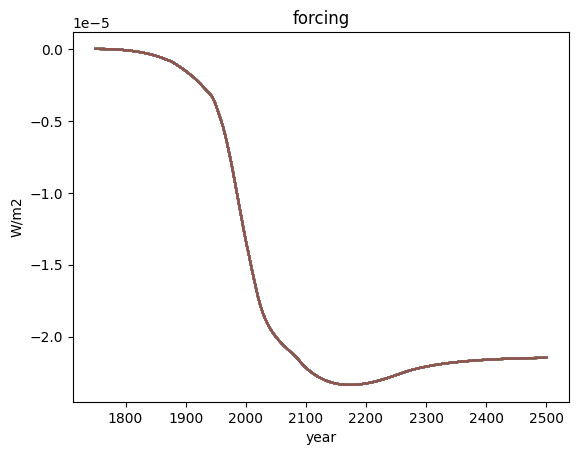

In [10]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp126', specie='CO2')], label=f.configs);
pl.title('forcing')
pl.xlabel('year')
pl.ylabel('W/m2')

Text(0, 0.5, 'W/m2')

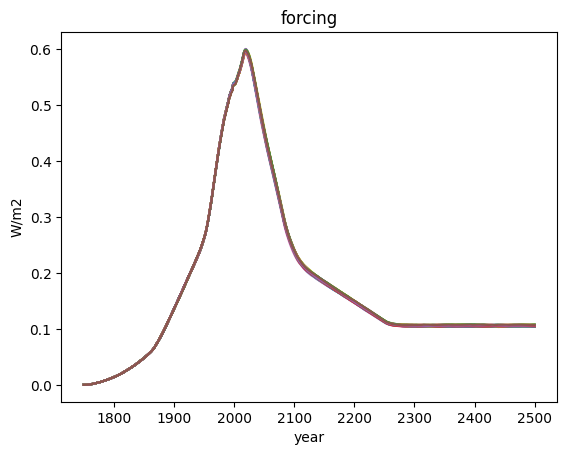

In [11]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp126', specie='CH4')], label=f.configs);
pl.title('forcing')
pl.xlabel('year')
pl.ylabel('W/m2')

Text(0, 0.5, 'W/m2')

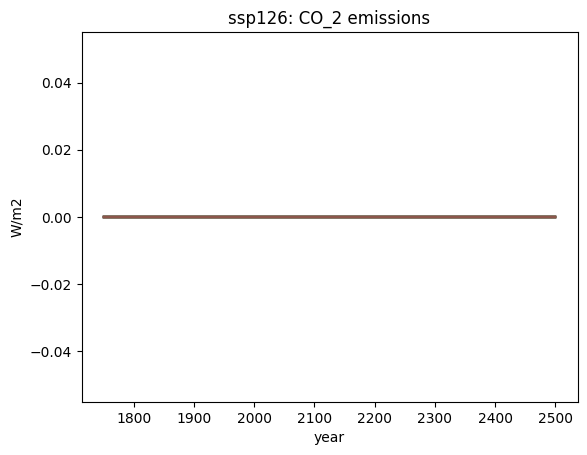

In [12]:
pl.plot(f.timepoints, f.emissions.loc[dict(scenario='ssp126', specie='CO2')], label=f.configs);
pl.title('ssp126: CO_2 emissions')
pl.xlabel('year')
pl.ylabel('W/m2')

Text(0, 0.5, 'Temperature anomaly (K)')

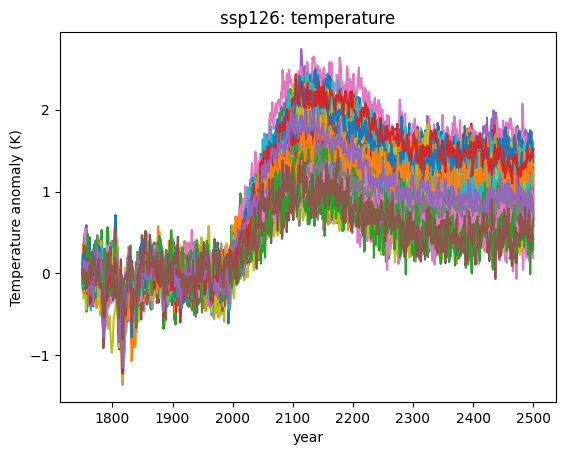

In [13]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp585', layer=0)], label=f.configs);
pl.title('ssp126: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')

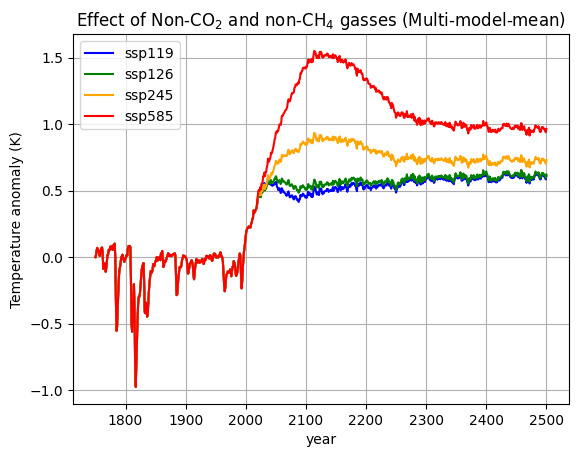

In [14]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config'),'b',label='ssp119');
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp126', layer=0)].mean(dim='config'),'g',label='ssp126');
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp245', layer=0)].mean(dim='config'),'orange',label='ssp245');
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config'),'r',label='ssp585');

#pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (Multi-model-mean)')
pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (Multi-model-mean)')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')
pl.legend()
pl.grid()

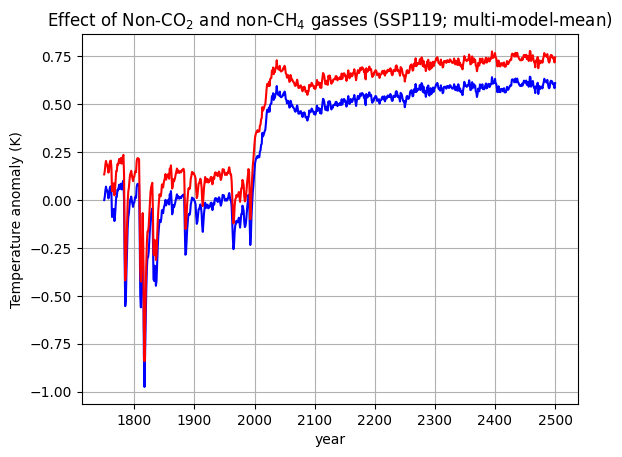

In [21]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config'),'b',label='Anomaly from 1750');
preIndMean = f.temperature.loc[dict(scenario='ssp119', layer=0)][f.timebounds<1850].mean(dim='config').mean(dim='timebounds')
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config')-preIndMean,'r',label='Anomaly from <1850 mean');

#pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (Multi-model-mean)')
pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (SSP119; multi-model-mean)')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')
pl.grid()


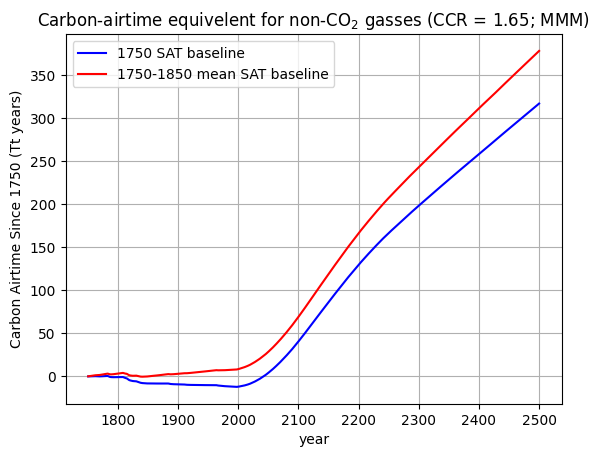

In [16]:
CCR = 1.65;
yr1 = 1750

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'b',label='1750 SAT baseline');

cum_emiss_eq2=(f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')-preIndMean)/CCR
CATe2 = np.cumsum(cum_emiss_eq2[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe2,'r',label='1750-1850 mean SAT baseline');

pl.title('Carbon-airtime equivelent for non-CO$_2$ gasses (CCR = 1.65; MMM)')
#pl.title('non-CO$_2$ and non-CH$_4$ Carbon Airtime equiv. (CCR = 1.5; MMM)')

pl.xlabel('year')
pl.ylabel('Carbon Airtime Since 1750 (Tt years)')
pl.legend()
pl.grid()

In [18]:
offset=preIndMean
#offset = 0#Toggle to zero in case of setting 1750 as offset.
fair_pd = pd.DataFrame({'Year': f.timebounds,\
        'temp_ssp119': f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config')-offset,
        'temp_ssp126': f.temperature.loc[dict(scenario='ssp126', layer=0)].mean(dim='config')-offset,
        'temp_ssp245': f.temperature.loc[dict(scenario='ssp245', layer=0)].mean(dim='config')-offset,
        'temp_ssp370': f.temperature.loc[dict(scenario='ssp370', layer=0)].mean(dim='config')-offset,
        'temp_ssp585': f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')-offset})

<Axes: xlabel='Year'>

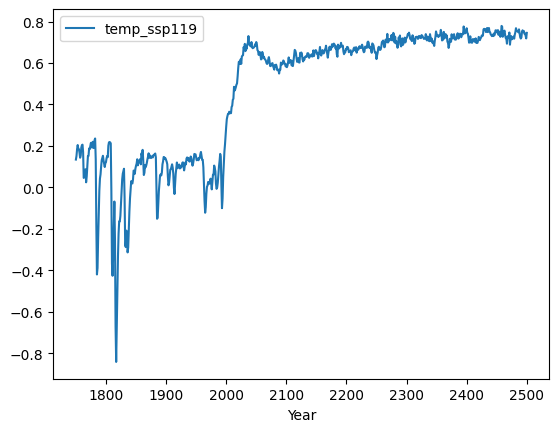

In [22]:
fair_pd.plot(x='Year',y='temp_ssp119')

In [20]:
'''
from google.colab import drive
drive.mount('/content/drive')
fair_pd.to_csv('FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv')
!cp FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv "/content/drive/My Drive/"
!fusermount -u /content/drive
'''

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\nfair_pd.to_csv(\'FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv\')\n!cp FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv "/content/drive/My Drive/"\n!fusermount -u /content/drive\n'